<a href="https://colab.research.google.com/github/miriamamin1213-ux/HPV-classification/blob/main/HPVEPOCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

from imblearn.over_sampling import SMOTE



In [2]:
df = pd.read_excel("HPVMODEL5.xlsx")

In [3]:
df.head ()

,PatientID,CenterID,Task 1,Task 2,Task 3,Age,Gender,Tobacco Consumption,Alcohol Consumption,Performance Status,Treatment,T-stage,N-stage,M-stage,HPV Status,Relapse,RFS
0,CHUM-001,1,1,1,0,82.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1704.0
1,CHUM-002,1,1,1,0,73.0,1,NaN,NaN,NaN,1.0,T3,N2,M0,NaN,1.0,439.0
2,CHUM-006,1,1,1,0,65.0,1,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1186.0
3,CHUM-007,1,1,1,0,70.0,0,NaN,NaN,NaN,0.0,T2,N2,M0,NaN,0.0,1702.0
4,CHUM-008,1,1,1,0,67.0,0,NaN,NaN,NaN,1.0,T2,N2,M0,NaN,0.0,1499.0


In [4]:
df.isnull().sum()

,0
PatientID,0
CenterID,0
Task 1,0
Task 2,0
Task 3,0
Age,0
Gender,0
Tobacco Consumption,212
Alcohol Consumption,218
Performance Status,263


In [5]:
df = df.dropna(subset=['HPV Status'])

In [6]:
tobacco_mode = df['Tobacco Consumption'].mode()[0]

df['Tobacco Consumption'] = df['Tobacco Consumption'].fillna(tobacco_mode)

In [7]:
alcohol_mode = df['Alcohol Consumption'].mode()[0]

df['Alcohol Consumption'] = df['Alcohol Consumption'].fillna(alcohol_mode)

In [8]:
df = df.drop(
    columns=[
        'Performance Status',
        'Relapse',
        'RFS',
        'PatientID',
        'CenterID',
        'Task 1',
        'Task 2',
        'Task 3'
    ]
)

In [9]:
df.isnull().sum()

,0
Age,0
Gender,0
Tobacco Consumption,0
Alcohol Consumption,0
Treatment,19
T-stage,3
N-stage,2
M-stage,2
HPV Status,0


In [10]:
df = df.dropna()

In [11]:
df.isnull().sum()

,0
Age,0
Gender,0
Tobacco Consumption,0
Alcohol Consumption,0
Treatment,0
T-stage,0
N-stage,0
M-stage,0
HPV Status,0


In [12]:
df.shape

(562, 9)

In [13]:
df['T-stage'] = df['T-stage'].replace({
    'T0':0,
    'T1':1,
    'T2':2,
    'T3':3,
    'T4':4
})

/tmp/ipykernel_6153/630066328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['T-stage'] = df['T-stage'].replace({


In [14]:
df['N-stage'] = df['N-stage'].replace({
    'N0':0,
    'N1':1,
    'N2':2,
    'N3':3
})

/tmp/ipykernel_6153/622728836.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['N-stage'] = df['N-stage'].replace({


In [15]:
df['M-stage'] = df['M-stage'].replace({
    'M0':0,
    'M1':1
})

/tmp/ipykernel_6153/752138774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['M-stage'] = df['M-stage'].replace({


In [16]:
print(df['T-stage'].unique())
print(df['N-stage'].unique())
print(df['M-stage'].unique())

[2 4 3 1 0]
[1 2 3 0]
[0 1]


In [17]:
X = df[
    [
        'Age',
        'Gender',
        'Tobacco Consumption',
        'Alcohol Consumption',
        'Treatment',
        'T-stage',
        'N-stage',
        'M-stage'
    ]
]

y = df['HPV Status']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
print(X_train.shape)
print(X_test.shape)

(449, 8)
(113, 8)


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [22]:
print(pd.Series(y_train_smote).value_counts())

HPV Status
1.0    407
0.0    407
Name: count, dtype: int64


In [23]:
import torch

X_train_smote = torch.tensor(
    X_train_smote,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_smote = torch.tensor(
    y_train_smote,
    dtype=torch.long
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.long
)

In [24]:
print(X_train_smote.shape)
print(y_train_smote.shape)

print(X_test.shape)
print(y_test.shape)

torch.Size([814, 8])
torch.Size([814])
torch.Size([113, 8])
torch.Size([113])


In [25]:
import torch.nn as nn

class HPVNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(8, 64)

        self.fc2 = nn.Linear(64, 32)

        self.fc3 = nn.Linear(32, 16)

        self.fc4 = nn.Linear(16, 2)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.relu(self.fc1(x))

        x = self.relu(self.fc2(x))

        x = self.relu(self.fc3(x))

        x = self.fc4(x)

        return x

In [26]:
model = HPVNet()

print(model)

HPVNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [28]:
losses = []

epochs = 500

best_loss = float('inf')

for epoch in range(epochs):

    outputs = model(X_train_smote)

    loss = criterion(
        outputs,
        y_train_smote
    )

    losses.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if loss.item() < best_loss:

        best_loss = loss.item()

        torch.save(
            model.state_dict(),
            'best_hpv_model.pth'
        )

    if (epoch + 1) % 50 == 0:

        print(
            f'Epoch [{epoch+1}/{epochs}], '
            f'Loss: {loss.item():.4f}'
        )

Epoch [50/500], Loss: 0.4262
Epoch [100/500], Loss: 0.2923
Epoch [150/500], Loss: 0.2133
Epoch [200/500], Loss: 0.1586
Epoch [250/500], Loss: 0.1178
Epoch [300/500], Loss: 0.0942
Epoch [350/500], Loss: 0.0807
Epoch [400/500], Loss: 0.0722
Epoch [450/500], Loss: 0.0662
Epoch [500/500], Loss: 0.0621


In [29]:
model.load_state_dict(
    torch.load('best_hpv_model.pth')
)

<All keys matched successfully>

In [30]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.22      0.14      0.17        14
           1       0.88      0.93      0.91        99

    accuracy                           0.83       113
   macro avg       0.55      0.54      0.54       113
weighted avg       0.80      0.83      0.82       113



In [32]:
print(
    predicted.unique(
        return_counts=True
    )
)

(tensor([0, 1]), tensor([  9, 104]))


In [33]:
type(X_train_smote)

torch.Tensor

In [34]:
X_train_smote = torch.tensor(
    X_train_smote,
    dtype=torch.float32
)


/tmp/ipykernel_6153/3321023969.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_smote = torch.tensor(


In [35]:
y_train_smote = torch.tensor(
    y_train_smote,
    dtype=torch.long
)

/tmp/ipykernel_6153/3207795127.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_smote = torch.tensor(


In [36]:
model = HPVNet()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [37]:
losses = []

epochs = 500

best_loss = float('inf')

for epoch in range(epochs):

    outputs = model(X_train_smote)

    loss = criterion(
        outputs,
        y_train_smote
    )

    losses.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if loss.item() < best_loss:

        best_loss = loss.item()

        torch.save(
            model.state_dict(),
            'best_hpv_model.pth'
        )

    if (epoch + 1) % 50 == 0:

        print(
            f'Epoch [{epoch+1}/{epochs}], '
            f'Loss: {loss.item():.4f}'
        )

Epoch [50/500], Loss: 0.4457
Epoch [100/500], Loss: 0.3230
Epoch [150/500], Loss: 0.2536
Epoch [200/500], Loss: 0.1739
Epoch [250/500], Loss: 0.1280
Epoch [300/500], Loss: 0.0988
Epoch [350/500], Loss: 0.0848
Epoch [400/500], Loss: 0.0758
Epoch [450/500], Loss: 0.0695
Epoch [500/500], Loss: 0.0653


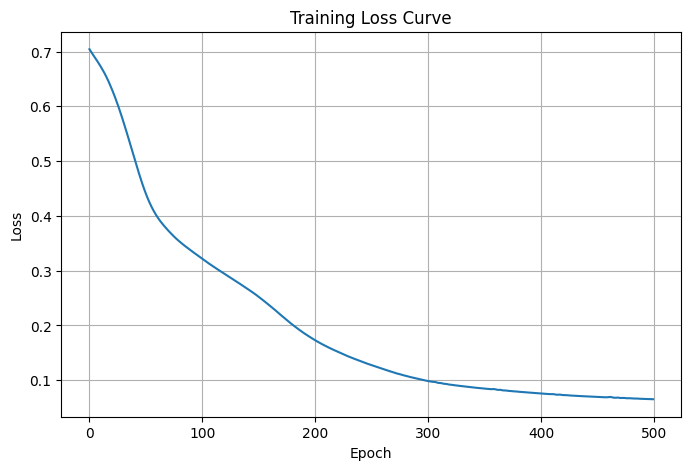

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training Loss Curve')

plt.grid(True)

plt.show()

In [39]:
X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

/tmp/ipykernel_6153/3430018460.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(


In [40]:
y_test = torch.tensor(
    y_test.values,
    dtype=torch.long
)

TypeError: 'builtin_function_or_method' object cannot be interpreted as an integer

In [ ]:
print(type(X_test))
print(type(y_test))

In [ ]:
model.load_state_dict(
    torch.load('best_hpv_model.pth')
)

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(outputs, dim=1)

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

print(cm)

In [ ]:
print(df['HPV Status'].value_counts())
print(df['HPV Status'].value_counts(normalize=True) * 100)

In [41]:
model.eval()

HPVNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=2, bias=True)
  (relu): ReLU()
)

In [43]:
with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(outputs, dim=1)

    hpv_positive_probs = probs[:,1]

In [44]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.641053391053391


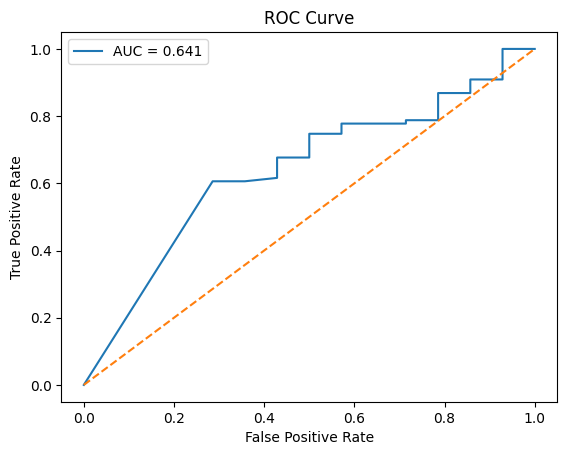

In [45]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

In [49]:
model = HPVNet()

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [50]:
losses = []

epochs = 1000

best_loss = float('inf')

best_epoch = 0

for epoch in range(epochs):

    outputs = model(X_train_smote)

    loss = criterion(
        outputs,
        y_train_smote
    )

    losses.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if loss.item() < best_loss:

        best_loss = loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            'best_hpv_model_1000.pth'
        )

    if (epoch + 1) % 100 == 0:

        print(
            f'Epoch [{epoch+1}/{epochs}], '
            f'Loss: {loss.item():.4f}'
        )

print("Best Loss =", best_loss)

print("Best Epoch =", best_epoch)

Epoch [100/1000], Loss: 0.3205
Epoch [200/1000], Loss: 0.1780
Epoch [300/1000], Loss: 0.1043
Epoch [400/1000], Loss: 0.0777
Epoch [500/1000], Loss: 0.0655
Epoch [600/1000], Loss: 0.0585
Epoch [700/1000], Loss: 0.0536
Epoch [800/1000], Loss: 0.0504
Epoch [900/1000], Loss: 0.0480
Epoch [1000/1000], Loss: 0.0462
Best Loss = 0.04617758095264435
Best Epoch = 1000


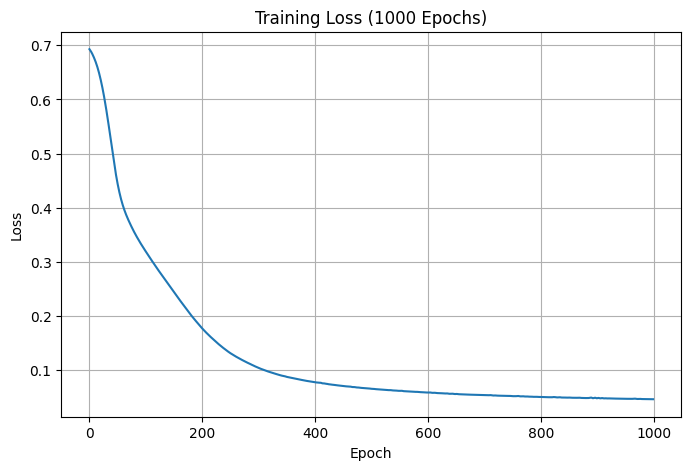

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Training Loss (1000 Epochs)')

plt.grid(True)

plt.show()

In [52]:
model.load_state_dict(
    torch.load('best_hpv_model_1000.pth')
)

<All keys matched successfully>

In [53]:
model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.09      0.07      0.08        14
           1       0.87      0.90      0.89        99

    accuracy                           0.80       113
   macro avg       0.48      0.49      0.48       113
weighted avg       0.78      0.80      0.79       113



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    predicted.numpy()
)

print(cm)

[[ 1 13]
 [10 89]]


In [56]:
with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(
        outputs,
        dim=1
    )

    hpv_positive_probs = probs[:,1]

In [57]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.5064935064935064


In [58]:
model = HPVNet()

In [59]:
weights = torch.tensor(
    [3.0, 1.0],
    dtype=torch.float32
)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [60]:
losses = []

epochs = 500

best_loss = float('inf')

best_epoch = 0

for epoch in range(epochs):

    outputs = model(X_train_smote)

    loss = criterion(
        outputs,
        y_train_smote
    )

    losses.append(loss.item())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if loss.item() < best_loss:

        best_loss = loss.item()

        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            'weighted_model.pth'
        )

print("Best Loss =", best_loss)

print("Best Epoch =", best_epoch)

Best Loss = 0.05701526626944542
Best Epoch = 500


In [61]:
model.load_state_dict(
    torch.load('weighted_model.pth')
)

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    predicted = torch.argmax(
        outputs,
        dim=1
    )

In [62]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.numpy(),
        predicted.numpy()
    )
)

              precision    recall  f1-score   support

           0       0.27      0.29      0.28        14
           1       0.90      0.89      0.89        99

    accuracy                           0.81       113
   macro avg       0.58      0.59      0.58       113
weighted avg       0.82      0.81      0.82       113



In [63]:
with torch.no_grad():

    outputs = model(X_test)

    probs = torch.softmax(
        outputs,
        dim=1
    )

    hpv_positive_probs = probs[:,1]

In [64]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test.numpy(),
    hpv_positive_probs.numpy()
)

print("AUC =", auc)

AUC = 0.7233044733044733
